In [ ]:
import numpy as np
import pandas as pd
import os.path as op
from parietal_patterns.utils.statistics import between_group_comparison
import pingouin

BIDS_ROOT = '/Users/mrenke/data/ds-dnumrisk'
group_df = pd.read_csv(op.join(BIDS_ROOT, 'group_assignment.csv')).set_index('subject')

PHENOTYPE_DIR = BIDS_ROOT + '/derivatives/phenotype'
plot_folder = '/Users/mrenke/obsidian-wiki/thesis/plots'

from numrisk.behavior_general.measures_registry import _load_magjudge_bauer, _load_npc_pfm_net_area, _load_iq_scores
magjudge_bauer_pcm_RDM = _load_magjudge_bauer(variant = 'v4_rdm')[['perceptual_noise_sd_v4_rdm']]
nPRF_r2 = pd.read_csv(op.join(PHENOTYPE_DIR, 'nPRF_r2area.csv')).set_index('subject')[['mean_R2']] # ,'area(r2>0.01)'

iq_me = _load_iq_scores()['me']
npc_pfm_net_area = _load_npc_pfm_net_area()[['Dorsal-attention_size']]


df_comb = magjudge_bauer_pcm_RDM.join(nPRF_r2).join(iq_me).join(npc_pfm_net_area).join(group_df)


In [ ]:
pretty_names_bn = {'perceptual_noise_sd_v4_rdm': 'PMC-RDM: Perceptual noise',
    'me': 'Visuospatial IQ (Matrizen)',
    'mean_R2': 'nPRF: mean R²',
    'Dorsal-attention_size': 'PFM: DAN area (in NPC mask)'}

<Axes: xlabel='Dorsal-attention_size', ylabel='mean_R2'>

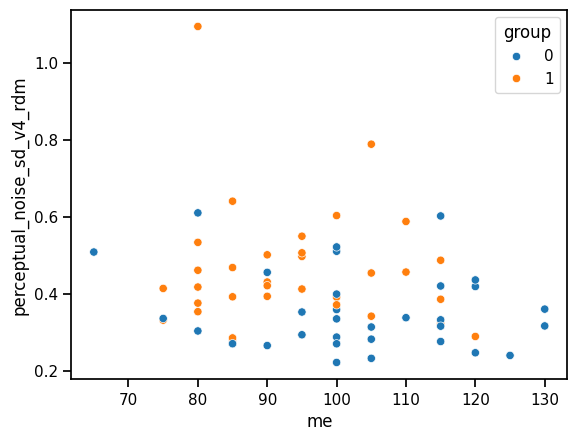

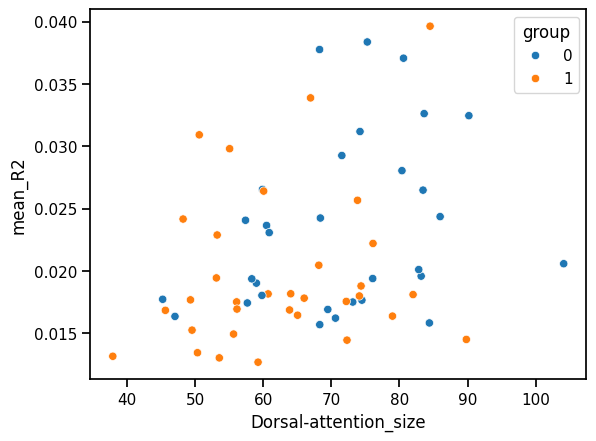

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('notebook')
sns.scatterplot(df_comb, x='me', y ='perceptual_noise_sd_v4_rdm', hue='group' )
plt.figure()
sns.scatterplot(df_comb, x='Dorsal-attention_size', y ='mean_R2', hue='group' )

In [22]:
df_comb

,perceptual_noise_sd_v4_rdm,mean_R2,me,Dorsal-attention_size,group,mean_early,mean_late
subject,,,,,,,
1,0.418600,0.016222,120.0,70.592925,0,-0.704654,NaN
2,0.602782,0.015260,100.0,49.514092,1,0.451395,NaN
3,0.601780,NaN,115.0,73.638125,0,NaN,NaN
4,0.456132,0.018114,110.0,81.994629,1,-0.159638,NaN
5,0.455303,0.017102,90.0,NaN,0,-0.315453,NaN
...,...,...,...,...,...,...,...
62,0.239678,0.024369,125.0,85.970049,0,-0.758752,NaN
63,0.315702,0.019376,115.0,58.296416,0,-0.962684,NaN
64,0.335675,0.037777,75.0,68.255664,0,1.905344,NaN


<Axes: xlabel='mean_early', ylabel='mean_late'>

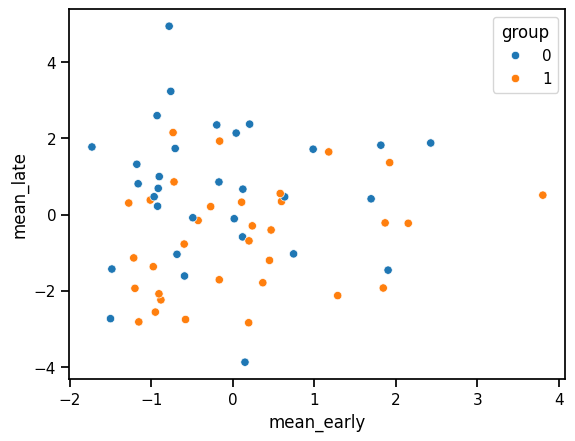

In [23]:
from scipy.stats import zscore

df_comb['mean_early'] = zscore(df_comb["perceptual_noise_sd_v4_rdm"], nan_policy="omit") + zscore(df_comb["mean_R2"], nan_policy="omit")# , nan_policy="omit"
df_comb['mean_late'] = zscore(df_comb["me"], nan_policy="omit") + zscore(df_comb["Dorsal-attention_size"], nan_policy="omit")# , nan_policy="omit"

sns.scatterplot(df_comb, x='mean_early', y ='mean_late', hue='group' )